# Loading Responses

In [39]:
options(warn=1)
if(!require('lme4')) {
    install.packages('lme4', repos='https://cloud.r-project.org')
    library('lme4')
}
if(!require('readr')) {
    install.packages('readr', repos='https://cloud.r-project.org')
    library('readr')
}
if(!require('marginaleffects')) {
    install.packages('marginaleffects', repos='https://cloud.r-project.org')
    library('marginaleffects')
}
if(!require('car')) {
    install.packages('car', repos='https://cloud.r-project.org')
    library('car')
}
if(!require('ggplot2')) {
    install.packages('ggplot2', repos='https://cloud.r-project.org')
    library('ggplot2')
}
if(!require('parameters')) {
  install.packages('parameters', repos='https://cloud.r-project.org')
  library('parameters')
}
if(!require('performance')) {
  install.packages('performance', repos='https://cloud.r-project.org')
  library('performance')
}
df <- read_csv("../output/result_1763865486_20250506_20250506T.csv", na = "empty", col_select = c("Accuracy", "Group", "GroupKind", "Angle", "Proximity", "n_candidates", "Actor", "Candidates", "Stimulus_ID", "Prompt_ID", "Participant_ID", "list_id", "Run_ID", "Part", "Accuracy_head", "Wrongness", "Wrongness_head", "Wrongness_max", "Wrongness_exp"), col_types = cols(
    Accuracy = col_logical(),
    Group = col_factor(),
    GroupKind = col_factor(),
    Angle = col_factor(),
    Proximity = col_integer(),
    n_candidates = col_integer(),
    Actor = col_factor(c('X', 'Y')),
    Candidates = col_factor(),
    Stimulus_ID = col_factor(),
    Prompt_ID = col_factor(),
    Participant_ID = col_factor(),
    list_id = col_factor(),
    Run_ID = col_character(),
    Part = col_character(),
    Accuracy_head = col_logical(),
    Wrongness = col_integer(),
    Wrongness_head = col_integer(),
    Wrongness_max = col_integer(),
    Wrongness_exp = col_double(),
),show_col_types = TRUE)
df <- df[df$Group == "Qwen2.5-VL-72B-Instruct" & df$list_id != -1 & df$Part != "p0", ]
df$offset_logit <- qlogis(df$Wrongness_exp / df$Wrongness_max)
df$n_candidates_c <- as.numeric(scale(df$n_candidates, scale = FALSE))
df$Proximity_c    <- as.numeric(scale(df$Proximity, scale = FALSE))
strict_control <- glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))

Rows: 155393 Columns: 19
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Run_ID, Part
dbl (1): Wrongness_exp
int (5): Proximity, n_candidates, Wrongness, Wrongness_head, Wrongness_max
lgl (2): Accuracy, Accuracy_head
fct (9): Stimulus_ID, Prompt_ID, Participant_ID, Group, GroupKind, Angle, Ac...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [40]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: aarch64-apple-darwin20.0.0 (64-bit)
Running under: macOS 26.1

Matrix products: default
BLAS/LAPACK: /Users/zory/miniforge3/envs/py310/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] C.UTF-8/C.UTF-8/C.UTF-8/C/C.UTF-8/C.UTF-8

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] performance_0.14.0     parameters_0.28.3      ggplot2_3.5.1         
[4] car_3.1-3              carData_3.0-5          marginaleffects_0.25.1
[7] readr_2.1.5            lme4_1.1-35.5          Matrix_1.6-5          

loaded via a namespace (and not attached):
 [1] generics_0.1.4     lattice_0.22-6     hms_1.1.3          digest_0.6.37     
 [5] magrittr_2.0.3     evaluate_0.22      grid_4.3.3         estimability_1.5.1
 [9] pbdZMQ_0.3-14      mvtnorm_1.3-3      fastmap_1.2.0      jsonlite_2.0.0    
[13] backports_1.5.0    Formula_1

# Random effect structure

In [41]:
model1 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c * Angle * n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Actor:Candidates), data = df, family = binomial, control = strict_control)
model2 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c * Angle * n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID) + (1 | Actor:Candidates), data = df, family = binomial, control = strict_control)
model3 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c * Angle * n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df, family = binomial, control = strict_control)
model4 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c * Angle * n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID), data = df, family = binomial, control = strict_control)
compare_performance(model1, model2, model3, model4, rank = TRUE)

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

Some of the nested models seem to be identical and probably only vary in
  their random effects.

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

Following indices with missing values are not used for ranking: Sigma,
  Log_loss



Name,Model,R2_conditional,R2_marginal,ICC,RMSE,Sigma,Log_loss,AIC_wt,AICc_wt,BIC_wt,Performance_Score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
model3,glmerMod,0.8141807,0.01739533,0.8108911,0.2490897,1,NA,0.3518638,0.3515795,0.0256291219,0.82887018
model1,glmerMod,0.8141803,0.01739536,0.8108907,0.2490898,1,NA,0.1294424,0.1288775,0.0002701525,0.57104400
model4,glmerMod,0.8138940,0.01736953,0.8106043,0.2495069,1,NA,0.3791963,0.3801583,0.9639399895,0.43023339
model2,glmerMod,0.8138936,0.01736929,0.8106039,0.2495069,1,NA,0.1394974,0.1393847,0.0101607360,0.01319103


In [42]:
anova(model3, model4)

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model4,14,9838.553,9938.022,-4905.276,9810.553,NA,NA,NA
model3,15,9838.702,9945.277,-4904.351,9808.702,1.85038,1,0.1737392


In [43]:
isSingular(model1)
isSingular(model2)
isSingular(model3)
isSingular(model4)

[1] TRUE

[1] TRUE

[1] FALSE

[1] FALSE

In [44]:
model <- model3

# Main Effects

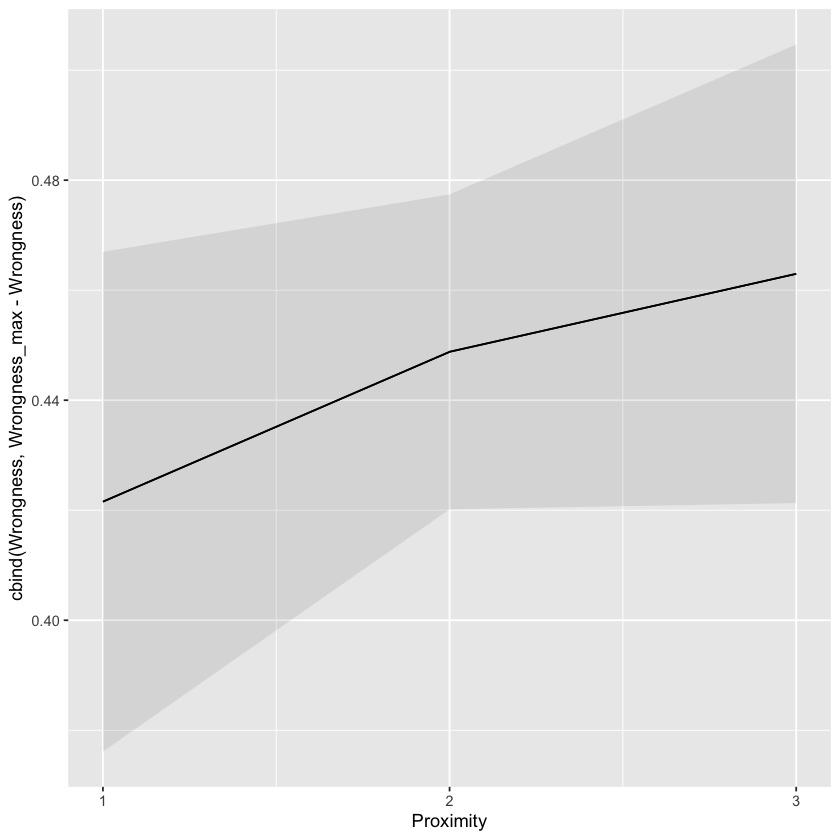

In [45]:
plot_predictions(model, by = c("Proximity")) +
    scale_x_continuous(breaks = c(1, 2, 3))

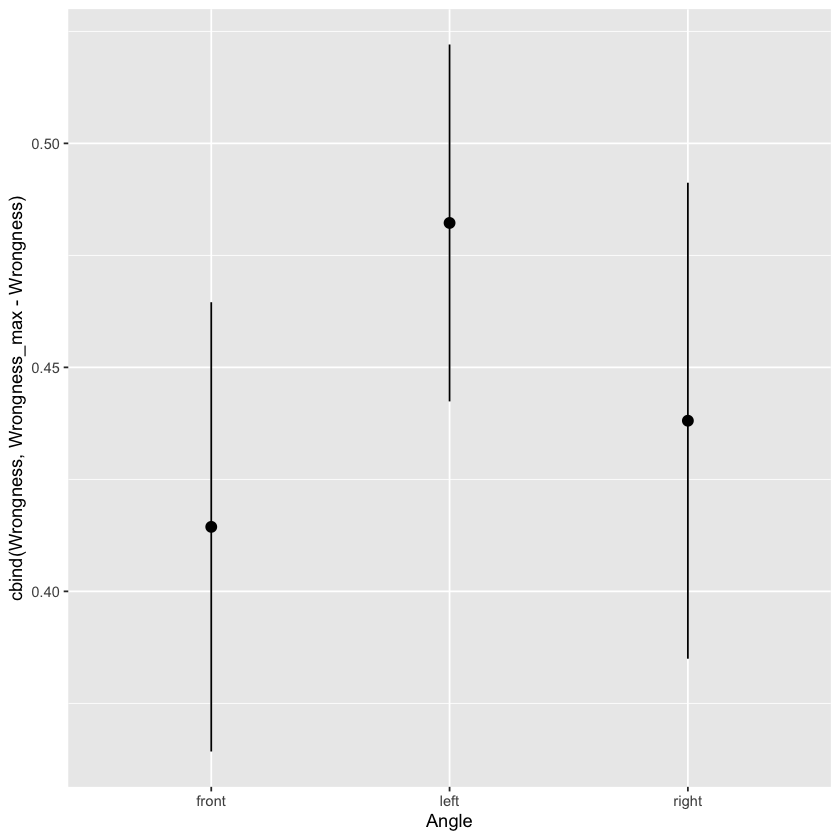

In [46]:
plot_predictions(model, by = c("Angle"))

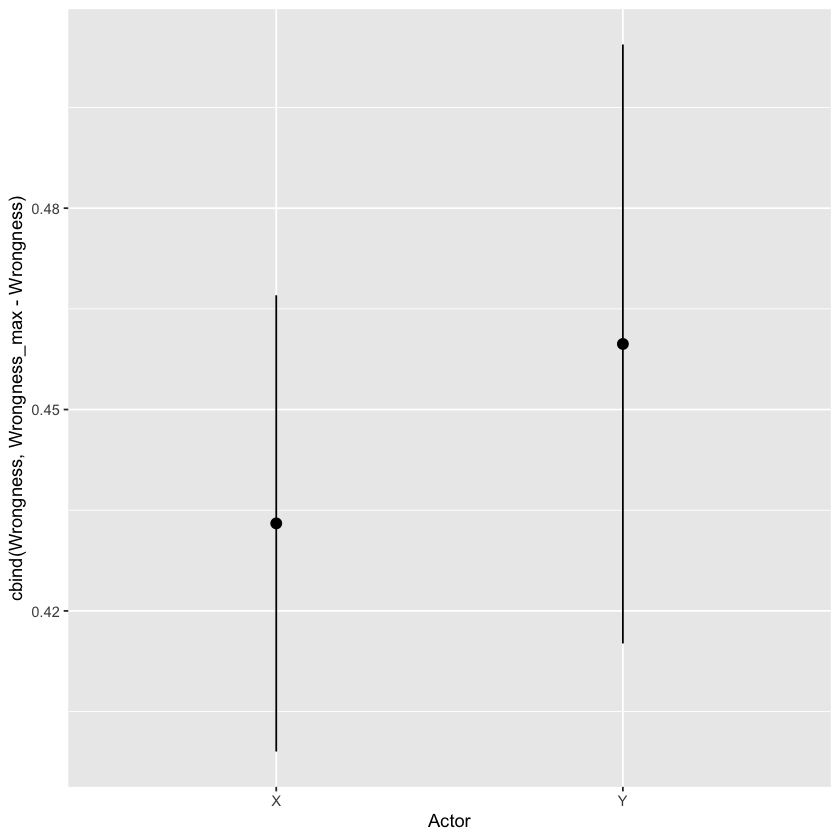

In [47]:
plot_predictions(model, by = c("Actor"))

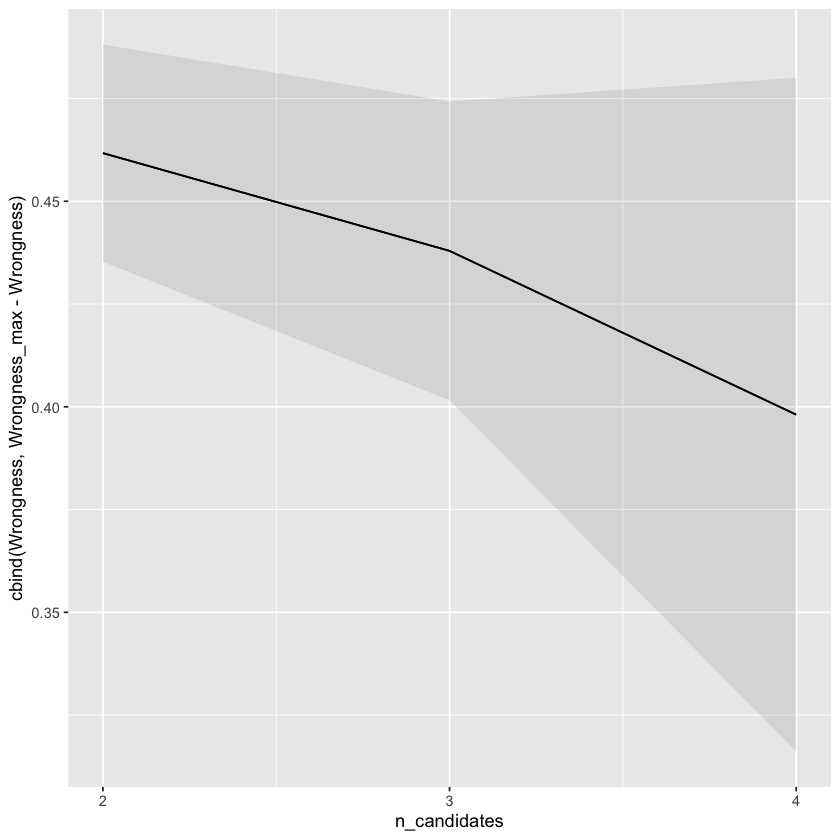

In [48]:
plot_predictions(model, by = c("n_candidates"))+ 
    scale_x_continuous(breaks = c(2, 3, 4))

In [49]:
avg_slopes(model, variables = "Proximity_c")
avg_slopes(model, variables = "n_candidates_c")
avg_comparisons(model, variables = "Angle")
avg_comparisons(model, variables = "Actor")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity_c,dY/dX,0.01962997,0.01713618,1.145527,0.2519907,1.988557,-0.01395633,0.05321627,0.7784298,0.7784262,0.778428


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates_c,dY/dX,-0.0286348,0.01681189,-1.703247,0.08852182,3.497823,-0.0615855,0.004315894,0.778436,0.7784201,0.778428


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.08698556,0.03239504,2.685151,0.00724971,7.107861,0.02349245,0.1504787
Angle,right - front,0.04730502,0.03259691,1.451212,0.14672092,2.768854,-0.01658375,0.1111938


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actor,Y - X,0.04049167,0.0272805,1.484271,0.137737,2.860012,-0.01297714,0.09396047,0.778428,0.831047,0.778428


Conclusion: No Proximity effect. Half View effect.

# Interpret interactions

In [50]:
model_null <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c + Angle + n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df, family = binomial, control = strict_control)
anova(model_null, model)

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_null,8,9831.569,9888.409,-4907.784,9815.569,NA,NA,NA
model,15,9838.702,9945.277,-4904.351,9808.702,6.866379,7,0.4429239


In [51]:
model <- model_null

# Report

In [52]:
summary(model)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c + Angle +  
    n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID) +  
    (1 | Prompt_ID)
   Data: df
Control: strict_control

     AIC      BIC   logLik deviance df.resid 
  9831.6   9888.4  -4907.8   9815.6     8992 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.9176 -0.1868 -0.0375  0.2042  4.4464 

Random effects:
 Groups      Name        Variance  Std.Dev.
 Stimulus_ID (Intercept) 10.032534 3.16742 
 Prompt_ID   (Intercept)  0.005187 0.07202 
Number of obs: 9000, groups:  Stimulus_ID, 900; Prompt_ID, 12

Fixed effects:
               Estimate Std. Error z value Pr(>|z|)    
(Intercept)     -1.0745     0.2205  -4.872  1.1e-06 ***
Proximity_c      0.1779     0.1376   1.293   0.1960    
Angleleft        0.6257     0.2758   2.269   0.0233 *  
Angleright       0.349

In [53]:
model_parameters(model)

Parameter,Coefficient,SE,CI,CI_low,CI_high,z,df_error,p,Effects,Group
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
(Intercept),-1.07451308,0.2205467,0.95,-1.50677674,-0.64224942,-4.872043,Inf,1.104504e-06,fixed,
Proximity_c,0.17790113,0.1375837,0.95,-0.09175796,0.44756023,1.293039,Inf,1.959975e-01,fixed,
Angleleft,0.62572893,0.2758243,0.95,0.08512325,1.16633462,2.268578,Inf,2.329400e-02,fixed,
Angleright,0.34949899,0.2743573,0.95,-0.18823138,0.88722936,1.273883,Inf,2.027050e-01,fixed,
n_candidates_c,-0.21005209,0.1414611,0.95,-0.48731067,0.06720649,-1.484876,Inf,1.375768e-01,fixed,
ActorY,0.33882594,0.2279499,0.95,-0.10794766,0.78559954,1.486405,Inf,1.371720e-01,fixed,
SD (Intercept),3.16741751,NA,0.95,NA,NA,NA,NA,NA,random,Stimulus_ID
SD (Intercept),0.07201869,NA,0.95,NA,NA,NA,NA,NA,random,Prompt_ID


In [54]:
Anova(model, type = 3)

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),23.736798,1,1.104504e-06
Proximity_c,1.671951,1,1.959975e-01
Angle,5.175591,2,7.518562e-02
n_candidates_c,2.204856,1,1.375768e-01
Actor,2.209401,1,1.371720e-01


In [55]:
vc_list <- lapply(VarCorr(model), function(x) attr(x, "stddev")^2)
vc <- sum(unlist(vc_list))
effect_size_denom_t <- sqrt(vc + pi^2/3)

res <- summary(model)$coefficients
res <- as.data.frame(res)
res <- cbind(term = rownames(res), res)
rownames(res) <- NULL
res$`Pr(>|z|)` <- format(res$`Pr(>|z|)`, scientific = FALSE)
res$CI_low <- res$Estimate - 1.96 * res$`Std. Error`
res$CI_high <- res$Estimate + 1.96 * res$`Std. Error`
res$effect_size_denom <- effect_size_denom_t
res$effect_size <- res$Estimate / effect_size_denom_t
res

term,Estimate,Std. Error,z value,Pr(>|z|),CI_low,CI_high,effect_size_denom,effect_size
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-1.0745131,0.2205467,-4.872043,0.000001104504,-1.50678469,-0.64224147,3.650697,-0.29433094
Proximity_c,0.1779011,0.1375837,1.293039,0.195997454732,-0.09176291,0.44756518,3.650697,0.04873073
Angleleft,0.6257289,0.2758243,2.268578,0.023294000049,0.08511331,1.16634455,3.650697,0.17139985
Angleright,0.3494990,0.2743573,1.273883,0.202704974610,-0.18824126,0.88723924,3.650697,0.09573487
n_candidates_c,-0.2100521,0.1414611,-1.484876,0.137576757777,-0.48731577,0.06721159,3.650697,-0.05753753
ActorY,0.3388259,0.2279499,1.486405,0.137171951277,-0.10795587,0.78560775,3.650697,0.09281130


The below code is for generating the table in the paper.

In [56]:
stim_id_var_val <- if (!is.null(vc_list$Stimulus_ID) && length(vc_list$Stimulus_ID) > 0) vc_list$Stimulus_ID[[1]] else NA_real_
prompt_id_var_val <- if (!is.null(vc_list$Prompt_ID) && length(vc_list$Prompt_ID) > 0) vc_list$Prompt_ID[[1]] else NA_real_
participant_id_var_val <- if (!is.null(vc_list$Participant_ID) && length(vc_list$Participant_ID) > 0) vc_list$Participant_ID[[1]] else NA_real_

intercept_est <- res[res$term == "(Intercept)", "Estimate"]
intercept_se <- res[res$term == "(Intercept)", "Std. Error"]

angleleft_est <- res[res$term == "Angleleft", "Estimate"]
angleleft_se <- res[res$term == "Angleleft", "Std. Error"]
angleleft_p_val <- res[res$term == "Angleleft", "Pr(>|z|)"]
angleleft_eff_size <- res[res$term == "Angleleft", "effect_size"]

angleright_est <- res[res$term == "Angleright", "Estimate"]
angleright_se <- res[res$term == "Angleright", "Std. Error"]
angleright_p_val <- res[res$term == "Angleright", "Pr(>|z|)"]
angleright_eff_size <- res[res$term == "Angleright", "effect_size"]

proximity_term_name <- "scale(Proximity, scale = FALSE)"
if (!proximity_term_name %in% res$term) {
    proximity_term_name <- grep("Proximity", res$term, value = TRUE)[1]
}
proximity_est <- res[res$term == proximity_term_name, "Estimate"]
proximity_se <- res[res$term == proximity_term_name, "Std. Error"]
proximity_p_val <- res[res$term == proximity_term_name, "Pr(>|z|)"]
proximity_eff_size <- res[res$term == proximity_term_name, "effect_size"]

n_candidates_term_name <- "scale(n_candidates, scale = FALSE)"
if (!n_candidates_term_name %in% res$term) {
    n_candidates_term_name <- grep("n_candidates", res$term, value = TRUE)[1]
}
n_obj_est <- res[res$term == n_candidates_term_name, "Estimate"]
n_obj_se <- res[res$term == n_candidates_term_name, "Std. Error"]
n_obj_p_val <- res[res$term == n_candidates_term_name, "Pr(>|z|)"]
n_obj_eff_size <- res[res$term == n_candidates_term_name, "effect_size"]

actory_term_name <- "ActorY" # Assuming 'X' is the reference level for Actor factor
actory_est <- res[res$term == actory_term_name, "Estimate"]
actory_se <- res[res$term == actory_term_name, "Std. Error"]
actory_p_val <- res[res$term == actory_term_name, "Pr(>|z|)"]
actory_eff_size <- res[res$term == actory_term_name, "effect_size"]

# Prepare data for data frame
table_data <- list(
    c("StimulusID", "Variance", sprintf("%.7f", stim_id_var_val)),
    c("ParticipantID", "Variance", sprintf("%.7f", participant_id_var_val)),
    c("PromptID", "Variance", sprintf("%.7f", prompt_id_var_val)),
    c("Effect Size Denom", "", sprintf("%.7f", effect_size_denom_t)),

    c("Intercept", "b", sprintf("%.7f", intercept_est)),
    c("", "SE", sprintf("%.7f", intercept_se)),

    c("Angleleft", "b", sprintf("%.7f", angleleft_est)),
    c("", "SE", sprintf("%.7f", angleleft_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleleft_p_val))),
    c("", "Effect size", sprintf("%.7f", angleleft_eff_size)),

    c("Angleright", "b", sprintf("%.7f", angleright_est)),
    c("", "SE", sprintf("%.7f", angleright_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleright_p_val))),
    c("", "Effect size", sprintf("%.7f", angleright_eff_size)),

    c("Proximity", "b", sprintf("%.7f", proximity_est)),
    c("", "SE", sprintf("%.7f", proximity_se)),
    c("", "p", sprintf("%.7f", as.numeric(proximity_p_val))),
    c("", "Effect size", sprintf("%.7f", proximity_eff_size)),

    c("#Object", "b", sprintf("%.7f", n_obj_est)),
    c("", "SE", sprintf("%.7f", n_obj_se)),
    c("", "p", sprintf("%.7f", as.numeric(n_obj_p_val))),
    c("", "Effect size", sprintf("%.7f", n_obj_eff_size)),

    c("ActorY", "b", sprintf("%.7f", actory_est)),
    c("", "SE", sprintf("%.7f", actory_se)),
    c("", "p", sprintf("%.7f", as.numeric(actory_p_val))),
    c("", "Effect size", sprintf("%.7f", actory_eff_size))
)

# Convert to data frame
df_output <- do.call(rbind, lapply(table_data, function(x) data.frame(V1=x[1], V2=x[2], V3=x[3], stringsAsFactors=FALSE)))

# Print only the third column for easy copy-pasting to Excel
write.table(df_output[,3, drop=FALSE], file="", sep = "\t", row.names = FALSE, col.names = FALSE, quote = FALSE)

10.0325337
NA
0.0051867
3.6506970
-1.0745131
0.2205467
0.6257289
0.2758243
0.0232940
0.1713999
0.3494990
0.2743573
0.2027050
0.0957349
0.1779011
0.1375837
0.1959975
0.0487307
-0.2100521
0.1414611
0.1375768
-0.0575375
0.3388259
0.2279499
0.1371720
0.0928113
